In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save model
import pickle

In [2]:
# ==========================================
# Load Dataset
# ==========================================

tasks = pd.read_csv("../data/processed/tasks_processed.csv")

In [3]:
tasks.head()

,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,Created_Date,Due_Date,Estimated_Hours,Actual_Hours,Assigned_To,Environment,Severity,Labels,SLA_Hours,Completion_Status
0,TASK-10001,Support: Investigate Payments,House answer start behind old travel Democrat ...,Support,Medium,Review,Apollo,Security,Sprint 7,1,2025-03-02,2025-03-08,2,1,EMP020,Development,Minor,support,96,Yes
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,2025-10-12,2025-10-16,2,1,EMP024,Production,Minor,documentation,48,No
2,TASK-10003,Enhancement: Fix UI,Recognize each off modern themselves role expl...,Enhancement,Low,Completed,Nova,Reporting,Sprint 4,3,2025-02-13,2025-03-04,6,6,EMP281,Production,Minor,enhancement,24,Yes
3,TASK-10004,UI/UX: Improve Notifications,Of then finish receive organization oil lay st...,UI/UX,Medium,Completed,Titan,Reporting,Sprint 10,8,2025-11-09,2025-11-17,16,20,EMP128,Development,Minor,ui-ux,48,No
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,2024-08-21,2024-09-08,6,11,EMP085,UAT,Minor,testing,48,Yes


In [4]:
tasks.shape

(10000, 20)

In [5]:
tasks.columns.tolist()

['Task_ID',
 'Task_Title',
 'Task_Description',
 'Category',
 'Priority',
 'Status',
 'Project_Name',
 'Module',
 'Sprint',
 'Story_Points',
 'Created_Date',
 'Due_Date',
 'Estimated_Hours',
 'Actual_Hours',
 'Assigned_To',
 'Environment',
 'Severity',
 'Labels',
 'SLA_Hours',
 'Completion_Status']

In [6]:
tasks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Task_ID            10000 non-null  object
 1   Task_Title         10000 non-null  object
 2   Task_Description   10000 non-null  object
 3   Category           10000 non-null  object
 4   Priority           10000 non-null  object
 5   Status             10000 non-null  object
 6   Project_Name       10000 non-null  object
 7   Module             10000 non-null  object
 8   Sprint             10000 non-null  object
 9   Story_Points       10000 non-null  int64 
 10  Created_Date       10000 non-null  object
 11  Due_Date           10000 non-null  object
 12  Estimated_Hours    10000 non-null  int64 
 13  Actual_Hours       10000 non-null  int64 
 14  Assigned_To        10000 non-null  object
 15  Environment        10000 non-null  object
 16  Severity           10000 non-null  object

Convert Dates

In [7]:
tasks["Created_Date"] = pd.to_datetime(tasks["Created_Date"])

tasks["Due_Date"] = pd.to_datetime(tasks["Due_Date"])

Task Duration

In [8]:
tasks["Task_Duration"] = (
    tasks["Due_Date"] -
    tasks["Created_Date"]
).dt.days

Delay Hours

In [9]:
tasks["Delay_Hours"] = (
    tasks["Actual_Hours"] -
    tasks["Estimated_Hours"]
)

Complexity Score

In [10]:
tasks["Complexity_Score"] = (
    tasks["Story_Points"] *
    tasks["Estimated_Hours"]
)

SLA Utilization

In [11]:
tasks["SLA_Utilization"] = (
    tasks["Estimated_Hours"] /
    tasks["SLA_Hours"]
)

Task Age

In [12]:
today = pd.Timestamp.today()

tasks["Task_Age"] = (
    today -
    tasks["Created_Date"]
).dt.days

Check New Dataset

In [13]:
tasks.head()

,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,...,Environment,Severity,Labels,SLA_Hours,Completion_Status,Task_Duration,Delay_Hours,Complexity_Score,SLA_Utilization,Task_Age
0,TASK-10001,Support: Investigate Payments,House answer start behind old travel Democrat ...,Support,Medium,Review,Apollo,Security,Sprint 7,1,...,Development,Minor,support,96,Yes,6,-1,2,0.020833,505
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,...,Production,Minor,documentation,48,No,4,-1,2,0.041667,281
2,TASK-10003,Enhancement: Fix UI,Recognize each off modern themselves role expl...,Enhancement,Low,Completed,Nova,Reporting,Sprint 4,3,...,Production,Minor,enhancement,24,Yes,19,0,18,0.250000,522
3,TASK-10004,UI/UX: Improve Notifications,Of then finish receive organization oil lay st...,UI/UX,Medium,Completed,Titan,Reporting,Sprint 10,8,...,Development,Minor,ui-ux,48,No,8,4,128,0.333333,253
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,...,UAT,Minor,testing,48,Yes,18,5,18,0.125000,698


Select Features

In [33]:
features = [
    "Category",
    "Module",
    "Sprint",
    "Project_Name",
    "Environment",
    "Severity",
    "Story_Points",
    "Estimated_Hours",
    "SLA_Hours",
    "Task_Duration"
]

Target

In [34]:
target = "Priority"

In [35]:
# ==========================================
# Create Model Dataset
# ==========================================

model_df = tasks[features + [target]].copy()

print("Dataset Shape:", model_df.shape)

model_df.head()

Dataset Shape: (10000, 11)


,Category,Module,Sprint,Project_Name,Environment,Severity,Story_Points,Estimated_Hours,SLA_Hours,Task_Duration,Priority
0,Support,Security,Sprint 7,Apollo,Development,Minor,1,2,96,6,Medium
1,Documentation,Authentication,Sprint 8,Vertex,Production,Minor,1,2,48,4,Medium
2,Enhancement,Reporting,Sprint 4,Nova,Production,Minor,3,6,24,19,Low
3,UI/UX,Reporting,Sprint 10,Titan,Development,Minor,8,16,48,8,Medium
4,Testing,Security,Sprint 14,Phoenix,UAT,Minor,3,6,48,18,Medium


In [36]:
# ==========================================
# Missing Value Analysis
# ==========================================

missing = model_df.isnull().sum()

print(missing)

Category           0
Module             0
Sprint             0
Project_Name       0
Environment        0
Severity           0
Story_Points       0
Estimated_Hours    0
SLA_Hours          0
Task_Duration      0
Priority           0
dtype: int64


In [37]:
model_df = model_df.dropna()

print(model_df.shape)

(10000, 11)


In [38]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Category         10000 non-null  object
 1   Module           10000 non-null  object
 2   Sprint           10000 non-null  object
 3   Project_Name     10000 non-null  object
 4   Environment      10000 non-null  object
 5   Severity         10000 non-null  object
 6   Story_Points     10000 non-null  int64 
 7   Estimated_Hours  10000 non-null  int64 
 8   SLA_Hours        10000 non-null  int64 
 9   Task_Duration    10000 non-null  int64 
 10  Priority         10000 non-null  object
dtypes: int64(4), object(7)
memory usage: 859.5+ KB


Encode Categorical Variables

In [42]:
categorical_columns = [
    "Category",
    "Module",
    "Sprint",
    "Project_Name",
    "Environment",
    "Severity",
    "Priority"
]

Encoding

In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    model_df[column] = encoder.fit_transform(model_df[column])

    label_encoders[column] = encoder

In [44]:
print(model_df.columns.tolist())

['Category', 'Module', 'Sprint', 'Project_Name', 'Environment', 'Severity', 'Story_Points', 'Estimated_Hours', 'SLA_Hours', 'Task_Duration', 'Priority']


In [49]:
model_df.head()

,Category,Module,Sprint,Project_Name,Environment,Severity,Story_Points,Estimated_Hours,SLA_Hours,Task_Duration,Priority
0,7,8,21,0,0,2,1,2,96,6,3
1,3,1,22,7,1,2,1,2,48,4,3
2,4,7,18,4,1,2,3,6,24,19,2
3,9,7,1,6,0,2,8,16,48,8,3
4,8,8,5,5,2,2,3,6,48,18,3


Split Features and Target

In [50]:
# ==========================================
# Split Features and Target
# ==========================================

X = model_df.drop("Priority", axis=1)

y = model_df["Priority"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (10000, 10)
Target Shape   : (10000,)


Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

Verify the Split

In [47]:
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (8000, 10)
Testing Shape : (2000, 10)


Train a Baseline Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(

    random_state=42

)

dt_model.fit(

    X_train,

    y_train

)

DecisionTreeClassifier(random_state=42)

Make Predictions

In [26]:
dt_predictions = dt_model.predict(

    X_test

)

Evaluate the Decision Tree

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, dt_predictions))

print("Precision :", precision_score(

    y_test,

    dt_predictions,

    average="weighted"

))

print("Recall :", recall_score(

    y_test,

    dt_predictions,

    average="weighted"

))

print("F1 Score :", f1_score(

    y_test,

    dt_predictions,

    average="weighted"

))

Accuracy : 0.7775
Precision : 0.7847581920903954
Recall : 0.7775
F1 Score : 0.7809488919419448


Classification Report

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [54]:
n_estimators=200
class_weight="balanced"
random_state=42
n_jobs=-1

Train the Model

In [55]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [56]:
print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


Make Predictions

In [ ]:
y_pred = rf_model.predict(X_test)

Evaluate the Model

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

Calculate the metrics

In [59]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

In [60]:
print("="*50)
print("Random Forest Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Random Forest Performance
Accuracy : 0.8525
Precision: 0.7782
Recall   : 0.8525
F1 Score : 0.7962


Classification Report

In [61]:
from sklearn.metrics import classification_report

# Get original priority names
priority_labels = label_encoders["Priority"].classes_

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=priority_labels
    )
)

Classification Report
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       234
        High       1.00      1.00      1.00       625
         Low       0.20      0.01      0.02       286
      Medium       0.75      0.99      0.85       855

    accuracy                           0.85      2000
   macro avg       0.74      0.75      0.72      2000
weighted avg       0.78      0.85      0.80      2000



Confusion Matrix

In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[234   0   0   0]
 [  0 625   0   0]
 [  0   0   3 283]
 [  0   0  12 843]]


Visualize the Confusion Matrix

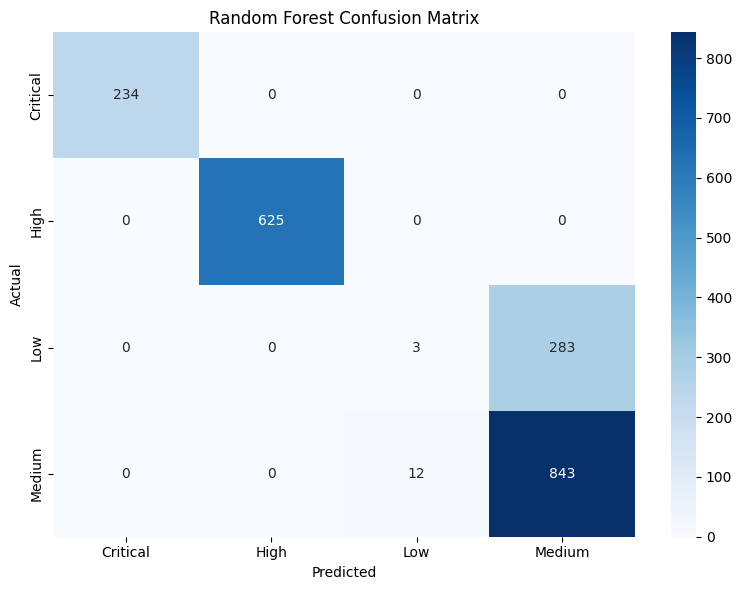

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=priority_labels,
    yticklabels=priority_labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/random_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

Feature Importance

In [64]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Severity,0.618687
9,Task_Duration,0.071241
2,Sprint,0.067494
0,Category,0.056242
1,Module,0.049483
3,Project_Name,0.043260
8,SLA_Hours,0.027925
4,Environment,0.022197
6,Story_Points,0.021749
7,Estimated_Hours,0.021721


The Random Forest model identified Severity as the most influential feature, contributing approximately 61.87% to the prediction of task priority. This aligns with real-world software development practices, where tasks with higher severity levels are generally assigned higher priorities. Other features such as Task Duration, Sprint, Category, and Module also contributed to the model's decision-making, while Estimated Hours and Story Points had relatively lower importance.

Feature Importance Visualization

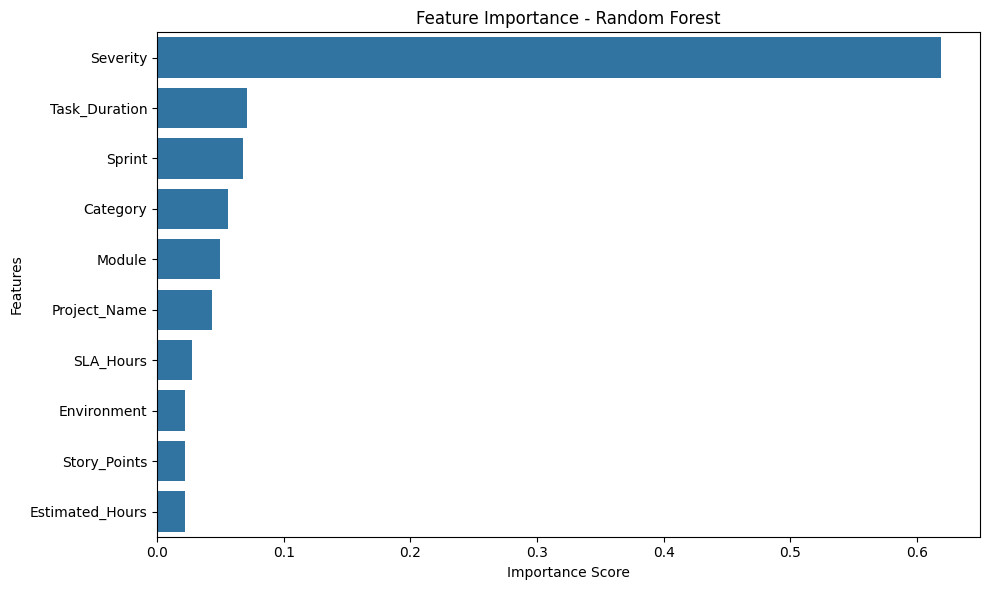

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/feature_importance_rf.png",
    dpi=300
)

plt.show()

Save the Trained Model

In [66]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Random Forest model
joblib.dump(
    rf_model,
    "../models/random_forest_priority_model.pkl"
)

# Save label encoders
joblib.dump(
    label_encoders,
    "../models/label_encoders.pkl"
)

print("Model and label encoders saved successfully!")

Model and label encoders saved successfully!


Hyperparameter Tuning using GridSearchCV

In [68]:
from sklearn.model_selection import GridSearchCV

Define Parameter Grid

In [69]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

Create Base Model

In [70]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

Create GridSearchCV

In [71]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

Train

In [72]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

Best Parameters

In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Best Cross-Validation Score

In [74]:
print("Best CV Score:")
print(grid_search.best_score_)

Best CV Score:
0.8547499999999999


Create Optimized Model

In [75]:
best_rf = grid_search.best_estimator_

Predict

In [76]:
y_pred_best = best_rf.predict(X_test)

Evaluate the Tuned Model

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("="*60)
print("GridSearchCV Random Forest")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_best, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_best, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

GridSearchCV Random Forest
Accuracy : 0.8535
Precision: 0.7827460106382979
Recall   : 0.8535
F1 Score : 0.7967039071235941

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00       625
           2       0.23      0.01      0.02       286
           3       0.75      0.99      0.85       855

    accuracy                           0.85      2000
   macro avg       0.74      0.75      0.72      2000
weighted avg       0.78      0.85      0.80      2000



Confusion Matrix

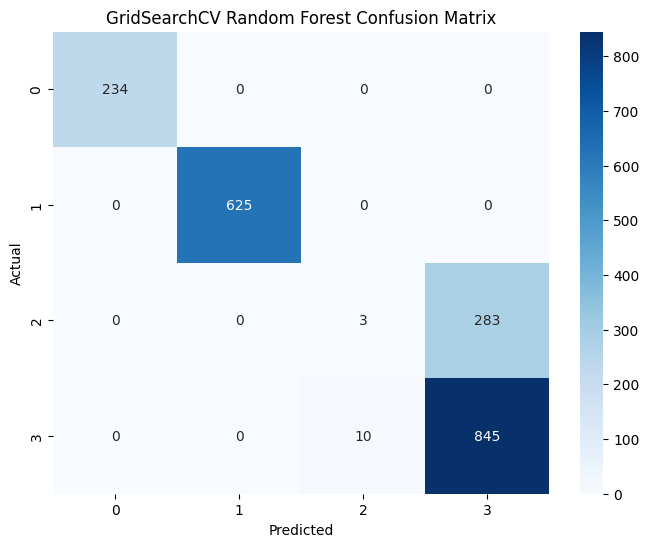

In [78]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GridSearchCV Random Forest Confusion Matrix")

plt.savefig("../outputs/charts/gridsearch_confusion_matrix.png")
plt.show()

Save the Optimized Model

In [79]:
import joblib

joblib.dump(best_rf, "../models/random_forest_gridsearch.pkl")

print("Optimized model saved successfully.")

Optimized model saved successfully.
